# 上海 H3N2 全周期参数锚定下的高校 SVEIR 模型

目标：尽可能复用 `pyepidemics` 库，基于已完成的上海市 SEIR 全周期拟合参数，构建一所高校场景的 SVEIR 传播模型。

建模思路：
- 先读取上海全周期数据与已拟合 SEIR 参数（`beta, sigma, gamma`）。
- 将这些参数作为高校模型锚点。
- 对高校特有机制引入合理先验：疫苗覆盖、疫苗保护效力与季节项。
- 基准情景不考虑免疫衰减与隔离环节。
- 输出高校场景下的一次完整流行周期曲线与关键指标。

In [1]:
import sys
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../../")

from pyepidemics.models.model import CompartmentalModel


# 1) 读取上海 H3N2 全周期数据
seir_data_path = Path("../../data/shanghai/seir_data.csv")
seir_data = pd.read_csv(seir_data_path)
seir_data["日期"] = pd.to_datetime(seir_data["日期"])
seir_data = seir_data.sort_values("日期").reset_index(drop=True)

# 2) 尝试从 seir/parameters.md 读取已拟合参数；若失败则使用你此前运行得到的结果
params_md_path = Path("../seir/parameters.md")
default_fit = {"beta": 0.8579778890300107, "sigma": 1.1613112937811108, "gamma": 0.7697576435552625}

seir_fit = default_fit.copy()
if params_md_path.exists():
    text = params_md_path.read_text(encoding="utf-8", errors="ignore")
    m = re.search(r"Found best solution\s*(\{.*?\})\s*for value", text, flags=re.S)
    if m:
        try:
            parsed = ast.literal_eval(m.group(1))
            if all(k in parsed for k in ["beta", "sigma", "gamma"]):
                seir_fit = {k: float(parsed[k]) for k in ["beta", "sigma", "gamma"]}
        except Exception:
            pass

print("SEIR fitted parameters used for anchoring:", seir_fit)
print("Shanghai cycle length (days):", len(seir_data))

SEIR fitted parameters used for anchoring: {'beta': 0.8579778890300107, 'sigma': 1.1613112937811108, 'gamma': 0.7697576435552625}
Shanghai cycle length (days): 231


## 高校场景先验参数设定（可解释、可调整）

参数来源分三类：
- 上海全周期 SEIR 拟合锚点：`beta, sigma, gamma`。
- 高校接触环境修正：`kappa_contact`（校园接触更密集）。
- 防控与生物学先验：疫苗覆盖率、疫苗有效性。

说明：
- 这里不再次拟合上海参数，而是将其作为跨场景迁移的基线。
- 基准情景默认免疫无衰减，且不考虑隔离转移。
- 高校模型用于“情景评估与策略比较”，后续可接入校内监测数据做二次校准。

In [2]:
# -------- 高校 SVEIR 参数先验（与 parameters/基础参数假设.md 同步） --------
N_campus = 28500.0  # 宝山校区核心传播人群规模先验

# 来自上海 SEIR 拟合的锚点参数
beta_sh = seir_fit["beta"]
sigma = seir_fit["sigma"]  # E->I
gamma = seir_fit["gamma"]  # I->R

# 校园环境修正：同步参数假设时取 1.0（直接使用拟合 beta）
kappa_contact = 1.0

# 季节波动：与参数假设同步
season_amp = 0.20
season_phase = 30.0

# 防控相关先验（与参数假设同步）
v_coverage0 = 0.10   # 单群体近似：总体初始覆盖率约 9%-10%
ve = 0.45            # 疫苗保护效力
nu = 0.0             # 基线情景下不额外施加持续接种


class CampusSVEIR(CompartmentalModel):
    def __init__(self, N, params):
        self.N = float(N)
        self.best_params = params.copy()
        self.reset(self.best_params)

    def reset(self, params):
        merged = self.best_params.copy()
        merged.update(params)
        self.best_params = merged
        p = self.best_params

        compartments = ["S", "V", "E", "I", "R"]
        super().__init__(compartments, initial_state="S", start_state="E")

        self.beta0 = self.make_callable(float(p["beta0"]))
        self.sigma = self.make_callable(float(p["sigma"]))
        self.gamma_i = self.make_callable(float(p["gamma_i"]))
        self.nu = self.make_callable(float(p["nu"]))

        self.ve = float(p["ve"])
        self.season_amp = float(p["season_amp"])
        self.season_phase = float(p["season_phase"])

        # SVEIR 转移（不含免疫衰减、不含隔离）
        self.add_transition("S", "V", lambda y, t: self.nu(y, t) * y["S"])
        self.add_transition("E", "I", lambda y, t: self.sigma(y, t) * y["E"])
        self.add_transition("I", "R", lambda y, t: self.gamma_i(y, t) * y["I"] )

        def lambda_t(y, t):
            season = 1.0 + self.season_amp * np.cos(2.0 * np.pi * (t - self.season_phase) / 365.0)
            beta_t = self.beta0(y, t) * season
            return beta_t * y["I"] / self.N

        self.add_transition("S", "E", lambda y, t: lambda_t(y, t) * y["S"] )
        self.add_transition("V", "E", lambda y, t: (1.0 - self.ve) * lambda_t(y, t) * y["V"] )

    def r0_anchor(self):
        return float(self.best_params["beta0"]) / float(self.best_params["gamma_i"] )


params_campus = {
    "beta0": beta_sh * kappa_contact,
    "sigma": sigma,
    "gamma_i": gamma,
    "nu": nu,
    "ve": ve,
    "season_amp": season_amp,
    "season_phase": season_phase,
}

# 初值：不含隔离状态
E0, I0, R0 = 2.0, 1.0, 0.0
V0 = N_campus * v_coverage0
S0 = N_campus - V0 - E0 - I0 - R0

init_state_campus = {"S": S0, "V": V0, "E": E0, "I": I0, "R": R0}

model = CampusSVEIR(N=N_campus, params=params_campus)
print("Campus SVEIR anchor R0:", round(model.r0_anchor(), 3))
print("Initial state sum:", sum(init_state_campus.values()))

Campus SVEIR anchor R0: 1.115
Initial state sum: 28500.0


In [3]:
# 在没有校内实测时，使用“上海 I 曲线形态”作为代理目标，对高校专属参数做二次校准
from pyepidemics.params.optimizer import ParamsOptimizer

obs_proxy = (
    seir_data.set_index("日期")[["传染者_I"]]
    .rename(columns={"传染者_I": "I"})
    .copy()
)

# 将上海 I 曲线缩放到高校量级（仅用于形态校准）
proxy_peak_ratio = 0.035  # 假设高校单日感染者峰值量级约为总人数的 3.5%
obs_proxy["I"] = obs_proxy["I"] / obs_proxy["I"].max() * (proxy_peak_ratio * N_campus)

base_params = params_campus.copy()

def build_init_state(v_coverage):
    E0, I0, R0 = 2.0, 1.0, 0.0
    V0 = N_campus * float(v_coverage)
    S0 = N_campus - V0 - E0 - I0 - R0
    return {"S": S0, "V": V0, "E": E0, "I": I0, "R": R0}

def objective_campus(p):
    local = base_params.copy()
    local["beta0"] = beta_sh * float(p["kappa_contact"] )
    local["nu"] = float(p["nu"] )
    local["season_amp"] = float(p["season_amp"] )
    local["season_phase"] = float(p["season_phase"] )

    init_state = build_init_state(p["v_coverage0"] )

    model.reset(local)
    pred_i = model.predict(obs_proxy, init_state=init_state)["I"].loc[obs_proxy.index]

    # 归一化 RMSE，强调形态拟合而非绝对规模
    y_true = obs_proxy["I"].values
    y_pred = pred_i.values
    err = np.sqrt(np.mean((y_pred - y_true) ** 2)) / (np.max(y_true) + 1e-12)

    penalty = 0.0
    if abs(local["season_amp"] - 0.20) > 0.10:
        penalty += (abs(local["season_amp"] - 0.20) - 0.10) * 2.0

    return float(err + penalty)

space_campus = {
    "kappa_contact": (0.90, 1.20),
    "nu": (0.0, 0.003),
    "season_amp": (0.10, 0.30),
    "season_phase": (0.0, 80.0),
    "v_coverage0": (0.06, 0.20),
}

opt_campus = ParamsOptimizer(model)
best_campus = opt_campus.run(
    true=obs_proxy,
    space=space_campus,
    init_state=build_init_state(0.10),
    objective_fn=objective_campus,
    n=700,
    early_stopping=140,
    save=False,
    show_progress_bar=True,
)

# 写回最终高校参数
params_campus["beta0"] = beta_sh * float(best_campus["kappa_contact"] )
params_campus["nu"] = float(best_campus["nu"] )
params_campus["season_amp"] = float(best_campus["season_amp"] )
params_campus["season_phase"] = float(best_campus["season_phase"] )

init_state_campus = build_init_state(best_campus["v_coverage0"] )
model.reset(params_campus)

print("Best campus-specific params:", best_campus)
print("Campus tuning best loss:", opt_campus.study.best_value)
print("Updated anchor R0:", round(model.r0_anchor(), 3))

Parameters Optimization:   0%|          | 0/700 [00:00<?, ?it/s]

... Early stopping - best value has not changed since 140 trials at 0.4560401053064128
... Found best solution {'kappa_contact': 0.961188564328171, 'nu': 6.015984040799884e-06, 'season_amp': 0.29194322934498285, 'season_phase': 79.99829219100623, 'v_coverage0': 0.19023665703727805} for value 0.4560401053064128
Best campus-specific params: {'kappa_contact': 0.961188564328171, 'nu': 6.015984040799884e-06, 'season_amp': 0.29194322934498285, 'season_phase': 79.99829219100623, 'v_coverage0': 0.19023665703727805}
Campus tuning best loss: 0.4560401053064128
Updated anchor R0: 1.071


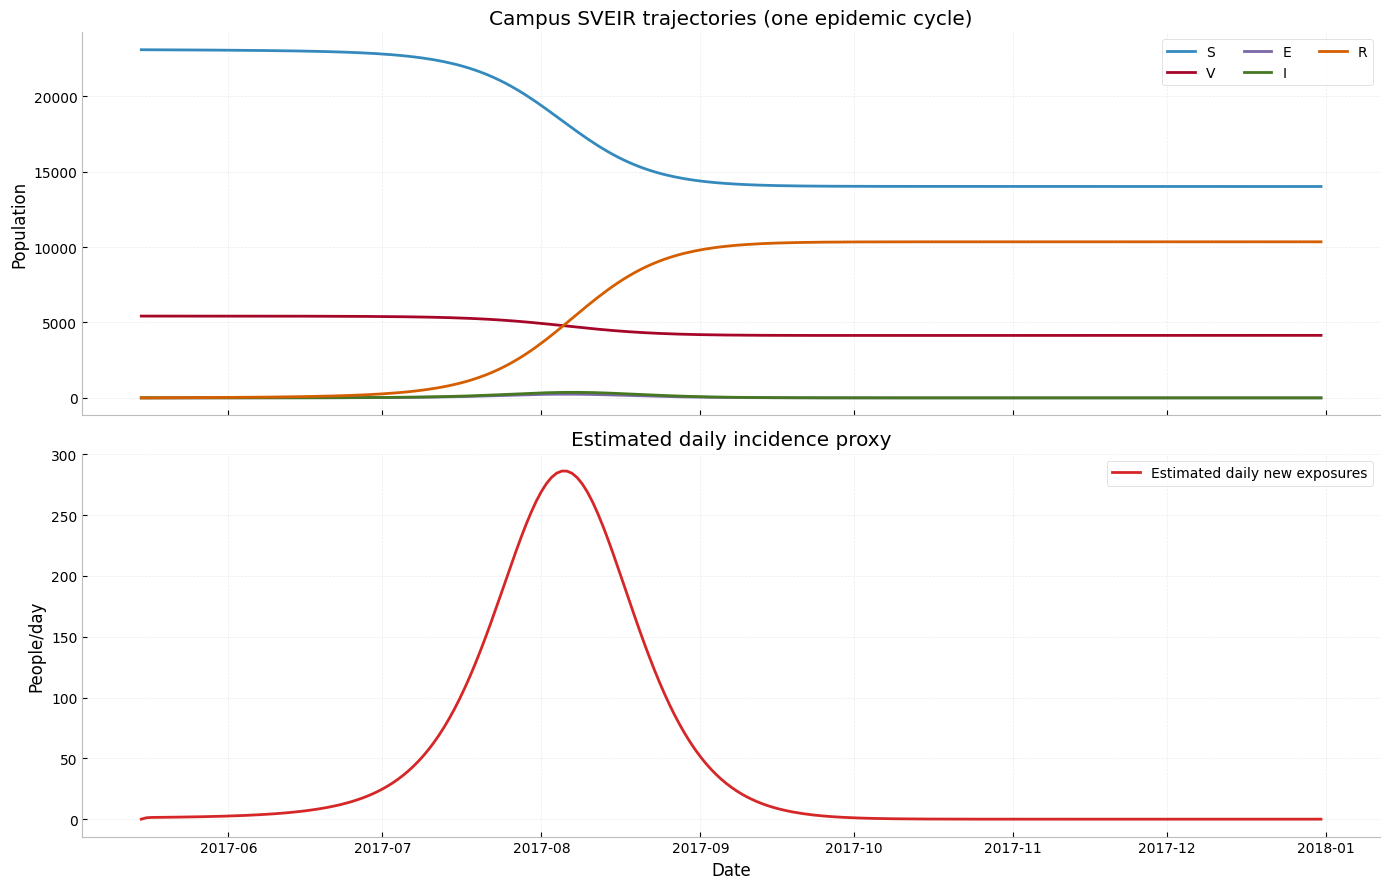

Peak infectious date: 2017-08-07 00:00:00
Peak infectious population: 369.4
Cycle attack rate (approx): 36.30%


In [4]:
# 按上海全周期长度模拟高校一个完整流行周期
n_days = int(len(seir_data) - 1)
pred = model.solve(n_days=n_days, init_state=init_state_campus)

# 增加日期索引，便于与上海周期并行展示
pred.index = seir_data["日期"].iloc[: len(pred)].values

# 日新增感染（S+V 向 E 的净流入近似）
new_exposed = -(pred["S"].diff() + pred["V"].diff()).fillna(0.0)
new_exposed = new_exposed.clip(lower=0.0)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(pred.index, pred["S"], label="S")
axes[0].plot(pred.index, pred["V"], label="V")
axes[0].plot(pred.index, pred["E"], label="E")
axes[0].plot(pred.index, pred["I"], label="I")
axes[0].plot(pred.index, pred["R"], label="R")
axes[0].set_title("Campus SVEIR trajectories (one epidemic cycle)")
axes[0].set_ylabel("Population")
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.25)

axes[1].plot(pred.index, new_exposed, color="tab:red", label="Estimated daily new exposures")
axes[1].set_title("Estimated daily incidence proxy")
axes[1].set_ylabel("People/day")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

peak_I_date = pred["I"].idxmax()
peak_I_value = float(pred["I"].max())
attack_rate = float((pred["R"].iloc[-1] - pred["R"].iloc[0]) / N_campus)

print("Peak infectious date:", peak_I_date)
print("Peak infectious population:", round(peak_I_value, 1))
print("Cycle attack rate (approx):", f"{attack_rate:.2%}")

,parameter,value,source
0,beta0,0.824679,Synced: Shanghai SEIR fitted beta (with kappa_...
1,sigma,1.161311,Synced: Shanghai SEIR fitted
2,gamma_i,0.769758,Synced: Shanghai SEIR fitted
3,ve,0.450000,Synced prior: vaccine effectiveness = 0.45
4,nu,0.000006,Synced prior: baseline ongoing vaccination rate
5,season_amp,0.291943,Synced prior: seasonal forcing amplitude = 0.20
6,season_phase,79.998292,Synced prior: seasonal phase = 30


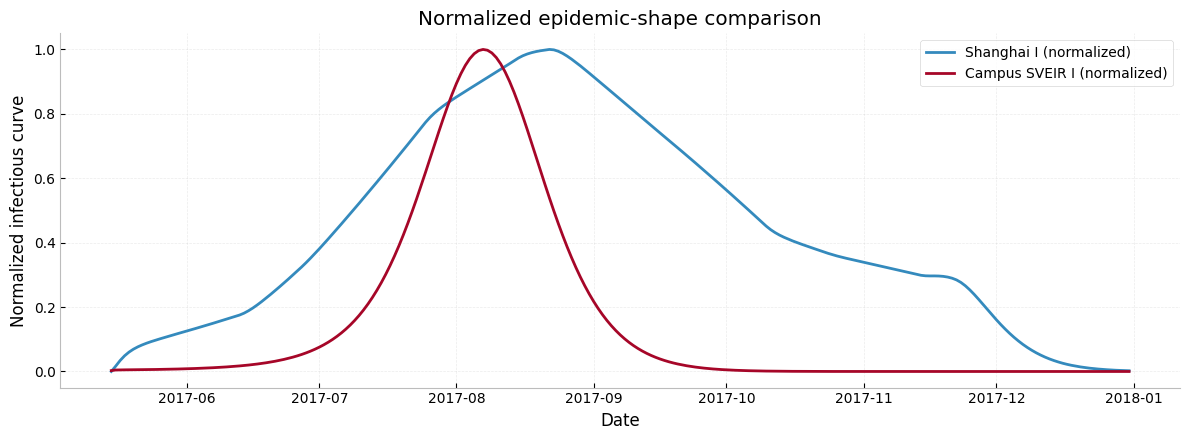

In [5]:
# 参数表：明确哪些来自上海拟合、哪些来自同步后的高校先验
param_table = pd.DataFrame(
    [
        ["beta0", params_campus["beta0"], "Synced: Shanghai SEIR fitted beta (with kappa_contact)"],
        ["sigma", params_campus["sigma"], "Synced: Shanghai SEIR fitted"],
        ["gamma_i", params_campus["gamma_i"], "Synced: Shanghai SEIR fitted"],
        ["ve", params_campus["ve"], "Synced prior: vaccine effectiveness = 0.45"],
        ["nu", params_campus["nu"], "Synced prior: baseline ongoing vaccination rate"],
        ["season_amp", params_campus["season_amp"], "Synced prior: seasonal forcing amplitude = 0.20"],
        ["season_phase", params_campus["season_phase"], "Synced prior: seasonal phase = 30"],
    ],
    columns=["parameter", "value", "source"],
)

display(param_table)

# 与上海 I 曲线做归一化形态对比（仅比较形态，不比较绝对规模）
sh_i = seir_data["传染者_I"].iloc[: len(pred)].to_numpy(dtype=float)
cp_i = pred["I"].to_numpy(dtype=float)

sh_i_norm = sh_i / (sh_i.max() + 1e-12)
cp_i_norm = cp_i / (cp_i.max() + 1e-12)

plt.figure(figsize=(12, 4.5))
plt.plot(seir_data["日期"].iloc[: len(pred)], sh_i_norm, label="Shanghai I (normalized)", lw=2)
plt.plot(pred.index, cp_i_norm, label="Campus SVEIR I (normalized)", lw=2)
plt.title("Normalized epidemic-shape comparison")
plt.xlabel("Date")
plt.ylabel("Normalized infectious curve")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()